# Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from lisatools.utils.constants import *
from copy import deepcopy  # can be useful
import h5py
import astropy

In [5]:

import matplotlib
# from matplotlib.image import NonUniformImage
# from scipy.stats import gmean
# imports 
# from bbhx.waveforms.phenomhm import PhenomHMAmpPhase
from lisatools.sensitivity import get_sensitivity
# from bbhx.waveformbuild import BBHWaveformFD
from eryn.prior import uniform_dist
from itertools import chain, repeat
import random
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from astropy.cosmology import z_at_value, Planck18, Planck13

# imports
from lisatools.sensitivity import AET1SensitivityMatrix
from lisatools.datacontainer import DataResidualArray
from lisatools.analysiscontainer import AnalysisContainer
import math
import pickle

# BH Data

In [7]:
df = pd.read_csv("jillian.txt", sep="\t", dtype={"time (Gyr)": float, "mass ratio": float, "redshift": float, "total BH mass (Msun)": float})

NameError: name 'pd' is not defined

In [6]:
time= df['time (Gyr)']
ratio= df['mass ratio']
z=np.array(df['redshift'])
M=df['total BH mass (Msun)']

NameError: name 'df' is not defined

In [6]:
m1=np.array(M/(1+ratio))

In [7]:
m2=np.array(ratio*m1)

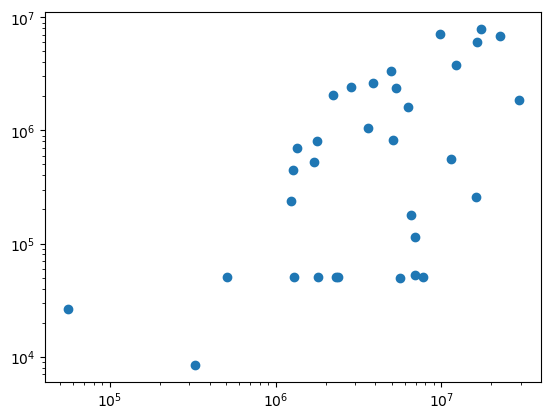

In [8]:
plt.loglog(m1,m2,'o')

In [9]:
cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089, Tcmb0=2.725)
d_l=np.array(cosmo.luminosity_distance(z).value/1e3) ## in Gpc

In [10]:
np.save('M_2_jillia.npy', m2)
np.save('M_1_jillia.npy', m1)
np.save('d_l_jillian.npy', d_l)
np.save('Z_jillian.npy', z)

# Functions

## SNR Calculators

In [60]:
arr_size = len(m1)
tdi_wave_gen = BBHWaveformFD()

def wrap(*args, **kwargs):
    return tdi_wave_gen(*args, **kwargs)[0]

def SNR_calc_stoch(m1 = m1, m2 = m2, dist = d_l, chi1 = np.full(arr_size, 0.5),
             chi2 = np.full(arr_size, 0.7), phi_ref = np.full(arr_size, 0.6),
             f_ref = np.full(arr_size, 0.0), inc = np.full(arr_size, np.pi / 8),
             lam = np.full(arr_size, 0.5), beta = np.full(arr_size, -0.7),
             psi = np.full(arr_size, np.pi / 4), t_ref = np.full(arr_size, 0.5 * YRSID_SI),
             num_elements = len(m1),obs=1,z=z,t_obs_end=1):
    length = 1024

    # Setup data holders
    Tobs = YRSID_SI / 12*obs    # 1 month
    dt = 10.0  # sec
    N = int(Tobs / dt)
    Tobs = N * dt

    freqs = np.fft.rfftfreq(N, dt)
    freqs=freqs[freqs>=10**(-4)]
    
    SNR_new = []

    for i in range(num_elements):
        AET_gen = tdi_wave_gen(
            m1[i],
            m2[i], 
            chi1[i],
            chi2[i],
            dist[i], 
            phi_ref[i],
            f_ref[i], 
            inc[i],
            lam[i],
            beta[i],
            psi[i],
            t_ref[i],
            t_obs_start=0,
            t_obs_end=t_obs_end,         
            length=1024, 
            combine=False,  # TODO: check this
            direct=False,
            fill=True,
            squeeze=True,
            freqs=freqs
        )
     
        data = DataResidualArray(AET_gen[0], f_arr=freqs)
        sens_mat = AET1SensitivityMatrix(data.f_arr,stochastic_params=(4.0 * YRSID_SI,))
        analysis = AnalysisContainer(data, sens_mat, signal_gen=wrap)
        snr = analysis.snr()
        SNR_new.append(snr)

    return SNR_new

## Parameter Generator

In [61]:
def draw_params(m1 = m1, 
                m2 = m2, dist = d_l,z=z,n=1): 
                
    arr_size=len(m1)*n
    
    znew = np.array(list(chain.from_iterable(repeat(x, n) for x in z)))
    m1new = np.array(list(chain.from_iterable(repeat(x, n) for x in m1)))*(znew+1)
    m2new = np.array(list(chain.from_iterable(repeat(x, n) for x in m2)))*(znew+1)
    distnew = np.array(list(chain.from_iterable(repeat(x, n) for x in dist)))
        

    # chi1 = np.full(arr_size, spin)
    # chi2 = np.full(arr_size, spin)
    
    phi_ref =  uniform_dist(0.0, 2 * np.pi).rvs(arr_size)
    f_ref = np.full(arr_size, 0)
    inc = np.arccos(uniform_dist(-1.0, 1.0).rvs(arr_size))
    lam = uniform_dist(0.0, 2 * np.pi).rvs(arr_size)
    beta = np.arcsin(uniform_dist(-1.0, 1.0).rvs(arr_size))
    psi = uniform_dist(0.0, np.pi).rvs(arr_size)
    t_ref = np.full(arr_size, 1e6)

    result={
         'm1'  : m1new,
         'm2'  : m2new,
         'z'   : znew,
        'dist' : distnew,
        # 'chi1':chi1,
        # 'chi2':chi2,
        'phi_ref': phi_ref,
        'f_ref': f_ref,
        'inc' : inc,
        'lam' : lam,
        'beta': beta,
        'psi' : psi,
        't_ref': t_ref,
        'num_elements':arr_size
    }
     
    return result

## Plotters

In [62]:
def avg_hist(x,y,z, bins=(20,20), c1='YlOrRd', c2= 'YlGnBu',  labelx=None, labely=None,
            labelz=None, norm1=matplotlib.colors.LogNorm(), logweight=True, 
            norm2=None, vmin=None,vmax=None):
 #            norm2=matplotlib.colors.LogNorm(vmin=None, vmax=None) ):
    z_mask=((~np.isnan(z))&(~np.isnan(x))&(~np.isnan(y)))
    x=x[z_mask]
    y=y[z_mask]
    z=z[z_mask]
    H_num, xedges, yedges = np.histogram2d(x, y, bins=bins)
    if logweight:
        z=np.log10(z)
    H_z, xedges, yedges = np.histogram2d(x,y, bins=(xedges, yedges), weights=z)
    H_num=H_num.T
    H_z=H_z.T
    plt.figure(figsize=(15,10))
    plt.subplot(2, 1, 1)
    plt.imshow(H_num, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
           cmap= c1, norm=norm1)
 
    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.colorbar(label='Numbers')

    plt.subplot(2,1,2)
    plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], 
               cmap=c2, norm=norm2, vmax=vmax,vmin=vmin)
    #print(np.min(H_z/H_num), np.max(H_z/H_num))
    #print(H_z/H_num)
   
    plt.xlabel(labelx)
    plt.ylabel(labely)
    plt.colorbar(label=labelz)
   
    
    plt.tight_layout()
    plt.gca().set_aspect('equal')


In [63]:
def y_mean_plotter(x, y, ybins=10, color='orange', marker='o', plt_type=True, xgmean=True, ygmean=True, plot=True):
    
    start = min(y)
    stop = max(y)
    
    if ygmean:
        values = np.logspace(np.log10(start), np.log10(stop), ybins)
    else:
        values = np.linspace(start, stop, ybins)
    x_mean = []
    y_mean = []

    for i in range(len(values)-1):
        mask_y = ((y > values[i]) & (y < values[i+1]) & (~np.isnan(x)))
        y_slice = values[i:i+2]
        if ygmean:
            y_mean.append(gmean(y_slice))
        else:
            y_mean.append(np.mean(y_slice))
        if xgmean:   
            x_mean.append(gmean(x[mask_y]))
        else:
            x_mean.append(np.mean(x[mask_y]))
        if plot:
            if plt_type:
                plt.plot(x_mean, y_mean, color=color, marker=marker)
            else:
                plt.scatter(x_mean, y_mean, color=color, marker=marker)

    return x_mean, y_mean

In [64]:
def x_mean_plotter(x, y, xbins=10, color='red', marker='o', plt_type=True, xgmean=True, ygmean=True, plot=True, label=None):
    
    start = min(x)
    stop = max(x)
    
    if xgmean:
        values = np.logspace(np.log10(start), np.log10(stop), xbins)
    else:
        values = np.linspace(start, stop, xbins)
    x_mean = []
    y_mean = []

    for i in range(len(values)-1):
        mask_x = ((x > values[i]) & (x < values[i+1]) & (~np.isnan(y)))
        x_slice = values[i:i+2]
        if xgmean:
            x_mean.append(gmean(x_slice))
        else:
            x_mean.append(np.mean(x_slice))
        if ygmean:   
            y_mean.append(gmean(y[mask_x]))
        else:
            y_mean.append(np.mean(y[mask_x]))
        if plot:
            if plt_type:
                plt.plot(x_mean, y_mean, color=color, marker=marker)
            else:
                plt.scatter(x_mean, y_mean, color=color, marker=marker)

    return x_mean, y_mean


# Analysis


In [20]:
pop_J=draw_params(n=10)

In [22]:
np.save('M_2_jillia.npy', m2)
np.save('M_1_jillia.npy', m1)
np.save('d_l_jillian.npy', d_l)
np.save('Z_jillian.npy', z)

In [16]:
snr_j=SNR_calc_stoch(**pop_J,chi1 = np.full(arr_size*10,.8),chi2 = np.full(arr_size*10, 0.8))

In [18]:
M_1=np.array(list(chain.from_iterable(repeat(x, 10) for x in m1)))
M_2=np.array(list(chain.from_iterable(repeat(x, 10) for x in m2)))
Z=np.array(list(chain.from_iterable(repeat(x, 10) for x in z)))


Text(0, 0.5, 'log(SNR)')

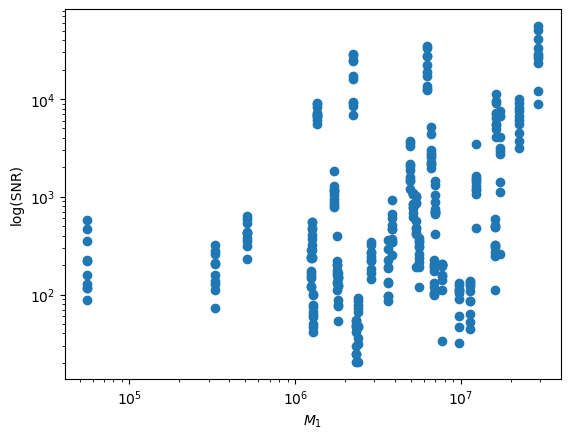

In [18]:
plt.loglog(M_1,snr_j,'o')
plt.xlabel('$M_1$')
plt.ylabel('log(SNR)')

Text(0, 0.5, '$SNR$')

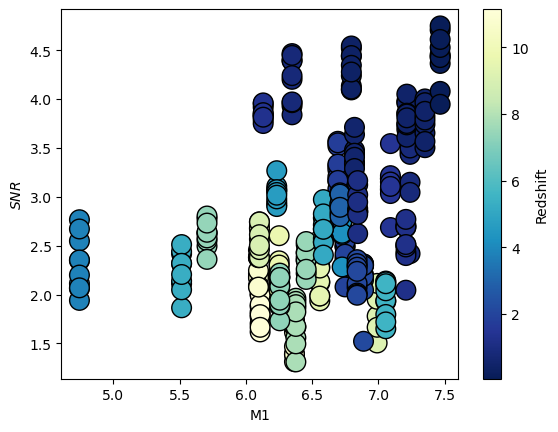

In [19]:

sc=plt.scatter(
      # X-axis
      # Y-axis
    np.log10(M_1),
    np.log10(snr_j),
      c=Z,  # Color by redshift
    cmap="YlGnBu_r",  # Choose a colormap (e.g., 'viridis', 'plasma', 'coolwarm')
    edgecolors="k", 
    alpha=1,s=200
)
cbar=plt.colorbar(sc)
cbar.set_label("Redshift")
plt.xlabel('M1')
plt.ylabel('$SNR'
'$')

In [20]:
# from lisatools.sources import EMRICalculationController

In [21]:
# from lisatools.sources import BBHCalculationController

In [22]:
# controller = BBHCalculationController(psd='lisatools.sensitivity.A1TDISens') 
# snr_bbh = controller.get_snr()

/tmp/ipykernel_1779/4001164011.py:25: RuntimeWarning: invalid value encountered in divide
  plt.imshow(H_z/H_num, interpolation='nearest', origin='lower',extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],


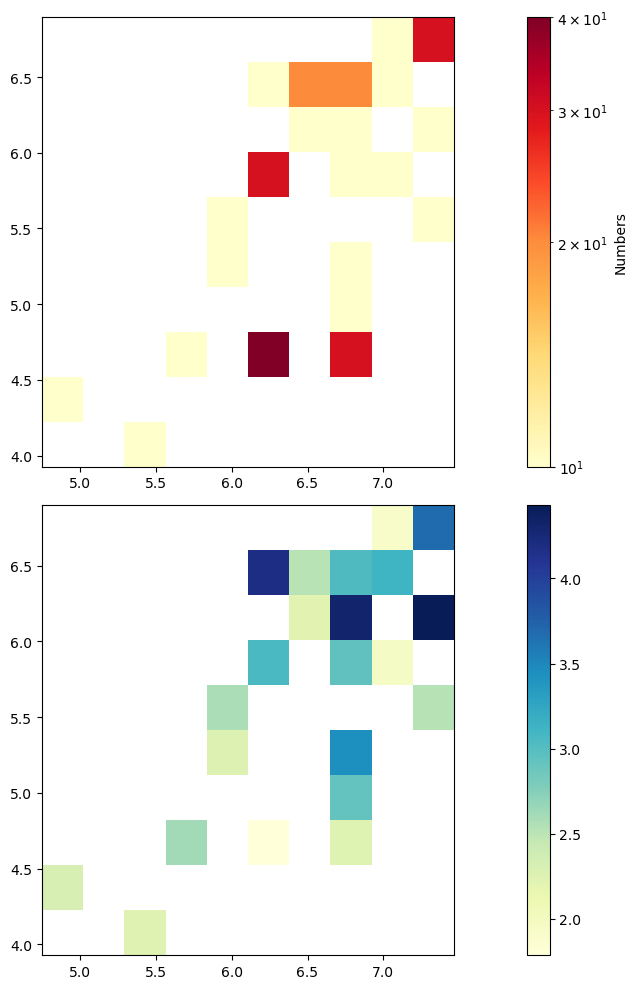

In [23]:
avg_hist(np.log10(M_1),np.log10(M_2),np.array(snr_j),bins=(10,10))

Text(0, 0.5, '$M_2$')

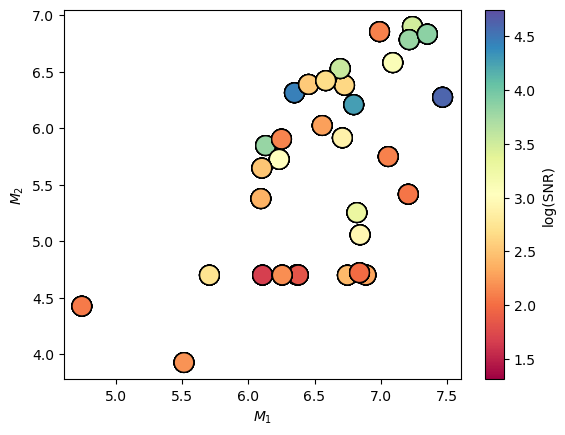

In [24]:
sc=plt.scatter(
    np.log10(M_1),  # X-axis
    np.log10(M_2),  # Y-axis
    c=np.log10(snr_j),  # Color by redshift
    cmap="Spectral",  # Choose a colormap (e.g., 'viridis', 'plasma', 'coolwarm')
    edgecolors="k", 
    alpha=1,s=200
)
cbar=plt.colorbar(sc)
cbar.set_label("log(SNR)")
plt.xlabel('$M_1$')
plt.ylabel('$M_2$')

Text(0, 0.5, '$log(SNR)$')

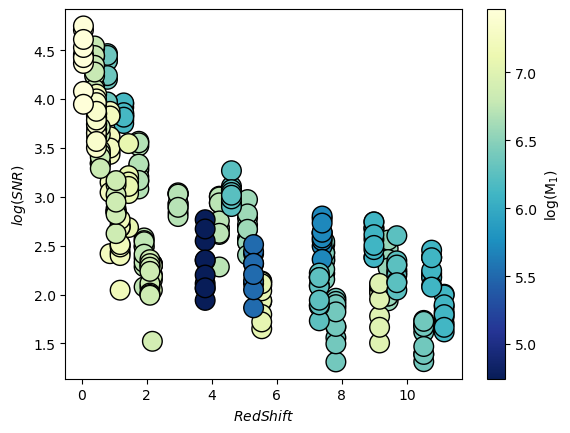

In [25]:

sc=plt.scatter(
    Z,  # X-axis
    np.log10(snr_j),  # Y-axis
    c=np.log10(M_1),  # Color by redshift
    cmap="YlGnBu_r",  # Choose a colormap (e.g., 'viridis', 'plasma', 'coolwarm')
    edgecolors="k", 
    alpha=1,s=200
)
cbar=plt.colorbar(sc)
cbar.set_label("log(M$_1$)")
plt.xlabel('$RedShift$')
plt.ylabel('$log(SNR)$')


Text(0, 0.5, '$log(SNR)$')

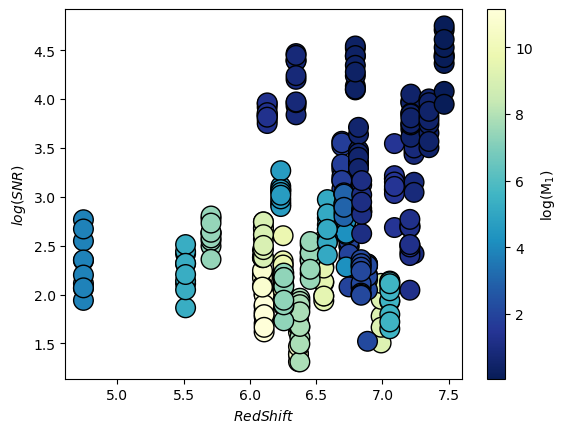

In [26]:

sc=plt.scatter(
    np.log10(M_1),  # X-axis
    np.log10(snr_j),  # Y-axis
    c=Z,  # Color by redshift
    cmap="YlGnBu_r",  # Choose a colormap (e.g., 'viridis', 'plasma', 'coolwarm')
    edgecolors="k", 
    alpha=1,s=200
)
cbar=plt.colorbar(sc)
cbar.set_label("log(M$_1$)")
plt.xlabel('$RedShift$')
plt.ylabel('$log(SNR)$')

In [27]:
snr_j

[100.75883783843209,
 75.23464264308072,
 66.20656442966737,
 50.461282288015745,
 41.47797859022721,
 59.24093627523017,
 98.97479347292922,
 78.67223001311041,
 62.36353073565412,
 46.21379845164064,
 119.7161046613844,
 192.63064575409595,
 379.5958023313399,
 314.4516926233447,
 237.2669120691456,
 306.5368625989089,
 356.51993948573687,
 213.25617872202875,
 347.01135946803936,
 258.8528758548036,
 6821.112829978545,
 8936.769256928737,
 6639.57158524931,
 6994.043356122918,
 8231.238434006347,
 6113.948734425299,
 9132.984930704202,
 7258.4802399303635,
 5616.852064481257,
 6522.52646935258,
 15907.231284325935,
 24973.219455647748,
 8502.499463095708,
 29162.111385777065,
 6896.514272131157,
 9177.674862505151,
 24563.159464457683,
 9339.211702156012,
 17365.104253966794,
 27956.47818344129,
 13554.019652554138,
 27337.329391746305,
 17298.8278502134,
 32992.10535943449,
 34889.743989861214,
 12400.91745822734,
 27859.93899873749,
 12650.322214224456,
 22120.426574345067,
 18893

Text(0, 0.5, 'redshift')

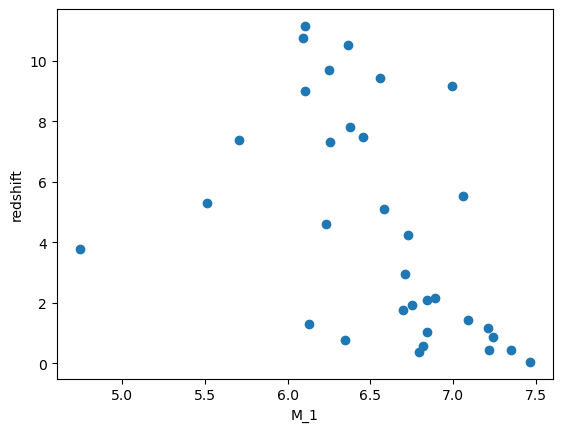

In [28]:
plt.scatter(np.log10(m1),z)
plt.xlabel('M_1')
plt.ylabel('redshift')


/tmp/ipykernel_1779/3251262282.py:21: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  y_mean.append(gmean(y[mask_x]))


([np.float64(0.05620385412015269),
  np.float64(0.07275034831195934),
  np.float64(0.09416815381017907),
  np.float64(0.121891391557225),
  np.float64(0.1577763897305028),
  np.float64(0.20422598214989351),
  np.float64(0.26435040031230467),
  np.float64(0.34217553226888564),
  np.float64(0.4429124932104189),
  np.float64(0.5733065580145442),
  np.float64(0.7420888200286877),
  np.float64(0.9605608188378675),
  np.float64(1.2433512832746971),
  np.float64(1.609395660642464),
  np.float64(2.083204020727699),
  np.float64(2.696502232548363),
  np.float64(3.490356305859269),
  np.float64(4.517922141803033),
  np.float64(5.8480048140440735),
  np.float64(7.569665707305511),
  np.float64(9.798186004011248)],
 [np.float64(nan),
  np.float64(nan),
  np.float64(nan),
  np.float64(nan),
  np.float64(nan),
  np.float64(nan),
  np.float64(nan),
  np.float64(nan),
  np.float64(3.964469092742668),
  np.float64(3.439571050817411),
  np.float64(4.177920040660473),
  np.float64(3.1383684332888144),
  

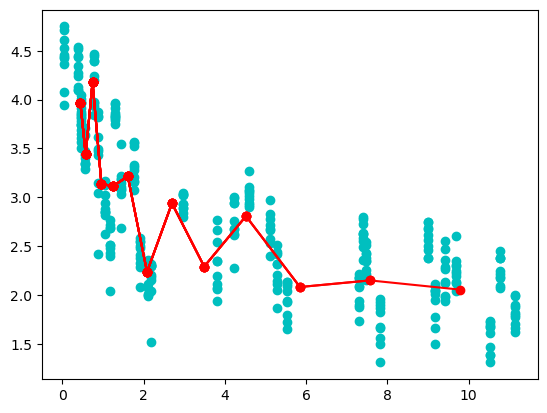

In [29]:
plt.scatter(Z,np.log10(snr_j),c='c')
x_mean_plotter( Z,np.log10(snr_j), xbins=22,color='r')

In [30]:
### Compare it with TNG

In [31]:
np.save('Z_jillian.npy',Z)

In [32]:
np.save('snr_Jillian.npy',snr_j)
np.save('M_1_jillia.npy',M_1)

# EMRIs

### EMRI Parameters

| Parameter        | Description                                               |
|------------------|-----------------------------------------------------------|
| `T`              | Duration of observation (in years)                        |
| `dt`             | Timestep in seconds                                       |
| `M`              | Mass of the primary black hole                            |
| `a`              | Spin of the primary black hole (ignored in Schwarzschild) |
| `mu`             | Mass of the secondary body (compact object)               |
| `p0`             | Initial semi-latus rectum                                 |
| `e0`             | Initial orbital eccentricity                              |
| `x0`             | Initial frequency parameter (ignored in Schwarzschild)    |
| `qK`             | Polar angle of the spin vector                            |
| `phiK`           | Azimuthal angle of the spin vector                        |
| `qS`             | Polar angle of the sky location                           |
| `phiS`           | Azimuthal angle of the sky location                       |
| `dist`           | Luminosity distance to the source (in Gpc)                |
| `Phi_phi0`       | Initial azimuthal phase                                   |
| `Phi_theta0`     | Initial polar phase                                       |
| `Phi_r0`         | Initial radial phase                                      |


In [11]:
### T Channel

In [11]:
from lisatools.sensitivity import SensitivityMatrix, A1TDISens, E1TDISens, AET1SensitivityMatrix

In [12]:
# sens_mat = SensitivityMatrix(data.f_arr, [AET1SensitivityMatrix])

## EMRI Functions

In [13]:
from lisatools.sources.emri import EMRITDIWaveform
# imports
from few.waveform import GenerateEMRIWaveform
bh=1
emri_lisa = EMRITDIWaveform(response_kwargs=dict(tdi_chan="AET"))

In [14]:
def emri_params(mu=m2, M=m1, dist=d_l,T=.1,n=1,p0=7): 
                
    arr_size=len(M)*n

    
    result = {
    'T': np.full(arr_size, T),  # years
    'dt': np.full(arr_size, 10),  # seconds
    'M': np.array(list(chain.from_iterable(repeat(x, n) for x in M))),
    'a': np.full(arr_size, 0.1),  # ignored in Schwarzschild waveform
    'mu': np.array(list(chain.from_iterable(repeat(x, n) for x in mu))),
    'p0': np.full(arr_size, p0),
    'e0': np.full(arr_size, 0.2),
    'x0': uniform_dist(-1, 1).rvs(arr_size),  # ignored in Schwarzschild waveform
    'qK': uniform_dist(0.0, np.pi).rvs(arr_size),  # polar spin angle
    'phiK': uniform_dist(0.0, 2 * np.pi).rvs(arr_size),  # azimuthal spin angle
    'qS': uniform_dist(0.0, np.pi).rvs(arr_size),  # polar sky angle
    'phiS': uniform_dist(0.0, 2 * np.pi).rvs(arr_size),  # azimuthal sky angle
    'dist': np.array(list(chain.from_iterable(repeat(x, n) for x in dist))),
    'Phi_phi0': np.full(arr_size, 1),
    'Phi_theta0': np.full(arr_size, 2),
    'Phi_r0': np.full(arr_size, 3)
}
    return result

## Analysis

In [15]:
# get the distance in GPC
# BISECTION SEARCH FOR p0

### Bisection Method for Root Finding

The **bisection method** is a root-finding technique that repeatedly narrows down an interval `[p_low, p_high]` where the function `f(p)` changes sign (i.e., `f(p_low) * f(p_high) < 0`) to find an approximate root `p` such that `f(p) ≈ 0`.
    """
    Basic bisection root-finding method to solve f(p) = 0.

    Parameters:
        f         : function to find root of (takes one argument: p)
        p_low     : lower bound of interval
        p_high    : upper bound of interval
        tol       : tolerance for stopping (default: 1e-6)
        max_iter  : maximum number of iterations (default: 100)

    Returns:
        Approximate root p such that f(p) ≈ 0
    """

In [16]:
def bisection_search(f, p_low, p_high, tol=1e-6, max_iter=100):
  
    f_low = f(p_low)
    f_high = f(p_high)

    if f_low * f_high > 0:
        raise ValueError("f(p_low) and f(p_high) must have opposite signs.")

    for i in range(max_iter):
        p_mid = (p_low + p_high) / 2
        f_mid = f(p_mid)


        print(f"[{i:02d}] p_low = {p_low:.6f}, p_high = {p_high:.6f}, f_low = {f_low:.4e}, f_high = {f_high:.4e}")

        if abs(f_mid) < tol:
            return p_mid

        if f_low * f_mid < 0:
            p_high = p_mid
            f_high = f_mid
        else:
            p_low = p_mid
            f_low = f_mid

    return (p_low + p_high) / 2


In [17]:
from lisatools.sources.emri import EMRITDIWaveform
emri_lisa = EMRITDIWaveform(T=15/52,response_kwargs=dict(tdi_chan="AET"))

def run_emri(params):
    return emri_lisa(
        params['M'], params['mu'], params['a'], params['p0'], params['e0'], params['x0'], params['dist'],
        params['qS'], params['phiS'], params['qK'], params['phiK'],
        params['Phi_phi0'], params['Phi_theta0'], params['Phi_r0'],
        T=params['T'], dt=params['dt']
    )

def run_emri(params):
    return emri_lisa(
        params['M'], params['mu'], params['a'], params['p0'], params['e0'], params['x0'], params['dist'],
        params['qS'], params['phiS'], params['qK'], params['phiK'],
        params['Phi_phi0'], params['Phi_theta0'], params['Phi_r0'],
        T=params['T'], dt=params['dt']
    )


def t_dur(parameters):
    AET = run_emri(parameters)
    not_z=np.argmax(AET[0][::-1]!=0)
    in_dex=len(AET[0])-not_z
    return in_dex*10



def emri_waveform(parameters):
    AET = run_emri(parameters)
    dt = parameters['dt']
    
    t_arr = np.arange(len(AET[0])) * dt

    fig, axes = plt.subplots(3, 1, sharex=True, gridspec_kw={'hspace': 0})
    labels = ['A channel', 'E channel', 'T channel']
    colors = ['tab:blue', 'tab:orange', 'tab:green']  # or pick your own

    for i in range(3):
        axes[i].plot(t_arr, AET[i].real, color=colors[i], label=labels[i])
        axes[i].set_ylabel('Strain')
        axes[i].legend()
        axes[i].grid(True)

    axes[-1].set_xlabel('Time [s]')
    # fig.suptitle('EMRI AET Time-Domain Waveform', fontsize=14)
    plt.show()

    return fig, axes


def adjust_emri_merger_time(parameters, target_time, tol=1e-3, max_iter=25,p_low=10,p_high=16):
    """
    Adjust the parameter 'p0' in the EMRI parameters to achieve a target merger time.
    
    Parameters:"""
    pars=dict(parameters)

    def p_func(p):
        pars=dict(parameters)
        pars['p0']=p
        a=t_dur(pars)-target_time
        return a

    p= bisection_search(p_func, p_low, p_high, tol, max_iter)

    pars['p0']=p

    return pars

In [37]:

bh=24
parameters = {
    'T': 2 / 52,  # duration in years
    'dt': 10.0,  # timestep in seconds
    'M': m1[bh],  # primary mass
    'a': 0.0,  # spin, ignored in Schwarzschild waveform
    'mu': m2[bh] / 100.0,  # secondary mass
    'p0': 16,  # initial semi-latus rectum
    'e0': 0,  # initial eccentricity
    'x0': 1.0,  # initial frequency param, ignored in Schwarzschild
    'qK': 0.0,  # polar spin angle
    'phiK': 0,  # azimuthal spin angle
    'qS': 0.3,  # polar sky angle
    'phiS': 0.3,  # azimuthal sky angle
    'dist': d_l[bh],  # luminosity distance in Gpc
    'Phi_phi0': 0.0,  # initial phase
    'Phi_theta0': 0.0,
    'Phi_r0': 0.0,
    'dt': 10,
}


/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/few/utils/baseclasses.py:416: UserWarning: Mass ratio is outside of generally accepted range for an extreme mass ratio (1e-4). (q=0.00016167399999999997)
  warnings.warn(


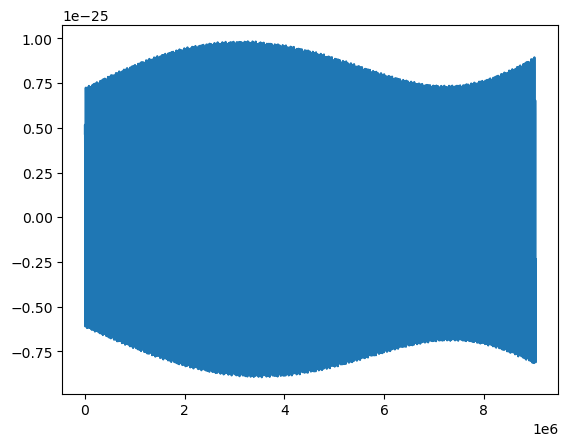

In [38]:
AET=run_emri(parameters)
not_z=np.argmax(AET[0][::-1]!=0)
in_dex=(len(AET[0])-not_z)
plt.plot(np.arange(int(in_dex) )* 10, AET[0].real[:int(in_dex)])
# plt.xlim(1.1e6,1.2e6)




In [34]:
parameters


{'T': 0.038461538461538464,
 'dt': 10,
 'M': np.float64(16098815.018076746),
 'a': 0.0,
 'mu': np.float64(260275.98192325394),
 'p0': 16,
 'e0': 0,
 'x0': 1.0,
 'qK': 0.0,
 'phiK': 0,
 'qS': 0.3,
 'phiS': 0.3,
 'dist': np.float64(8.318307088265946),
 'Phi_phi0': 0.0,
 'Phi_theta0': 0.0,
 'Phi_r0': 0.0}

In [18]:
m1[24],m2[24],d_l[24],z[24], m2[24]/m1[24]

(np.float64(16098815.018076746),
 np.float64(260275.98192325394),
 np.float64(8.318307088265946),
 np.float64(1.1786397),
 np.float64(0.0161674))

In [ ]:
new_pars=adjust_emri_merger_time(parameters, target_time=1e6, p_low=6.0, p_high=16)

: 

In [23]:
new_pars


{'T': 0.038461538461538464,
 'dt': 10,
 'M': np.float64(16098815.018076746),
 'a': 0.0,
 'mu': np.float64(260275.98192325394),
 'p0': 11.999488830566406,
 'e0': 0,
 'x0': 1.0,
 'qK': 0.0,
 'phiK': 0,
 'qS': 0.3,
 'phiS': 0.3,
 'dist': np.float64(8.318307088265946),
 'Phi_phi0': 0.0,
 'Phi_theta0': 0.0,
 'Phi_r0': 0.0}

/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/few/utils/baseclasses.py:416: UserWarning: Mass ratio is outside of generally accepted range for an extreme mass ratio (1e-4). (q=0.0161674)
  warnings.warn(


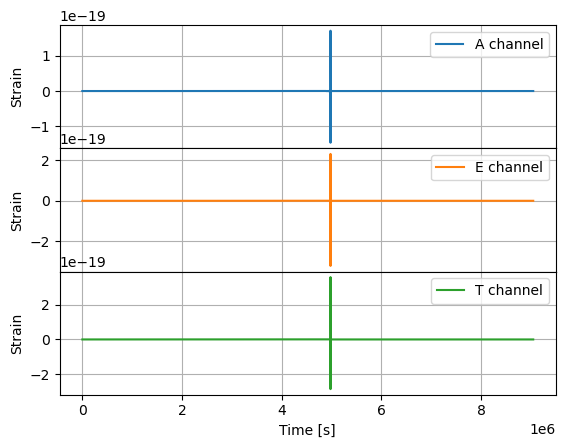

In [29]:
fig, ax= emri_waveform(parameters)

In [43]:
emri_lisa = EMRITDIWaveform(T=1.99/52,response_kwargs=dict(tdi_chan="AET"))

In [39]:
# fig, ax= emri_waveform(new_pars)
data = DataResidualArray(AET, dt=10)
sens_mat = AET1SensitivityMatrix(data.f_arr, stochastic_params=(4.0 * YRSID_SI,))
analysis = AnalysisContainer(data, sens_mat, signal_gen=emri_lisa)



/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:633: RuntimeWarning: divide by zero encountered in divide
  Sa_a = Sa_a_in * (1.0 + (0.4e-3 / frq) ** 2) * (1.0 + (frq / 8e-3) ** 4)
/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:635: RuntimeWarning: divide by zero encountered in power
  Sa_d = Sa_a * (2.0 * np.pi * frq) ** (-4.0)
/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:637: RuntimeWarning: invalid value encountered in multiply
  Sa_nu = Sa_d * (2.0 * np.pi * frq / C_SI) ** 2
/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:642: RuntimeWarning: divide by zero encountered in divide
  Soms_d = Soms_d_in * (1.0 + (2.0e-3 / f) ** 4)
/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/lisatools/detector.py:644: RuntimeWarning: invalid value encountered in multiply
  Soms_nu = Soms_d * (2.0 * np.pi * frq 

In [41]:
def EMRI_SNR(parameters):
    

    AET = run_emri(parameters)
    SNR_new = []
    data = DataResidualArray(AET, dt=10)
    sens_mat = AET1SensitivityMatrix(data.f_arr, stochastic_params=(4.0 * YRSID_SI,))
    analysis = AnalysisContainer(data, sens_mat, signal_gen=emri_lisa)
    snr = analysis.snr()
    SNR_new.append(snr)

    return SNR_new

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

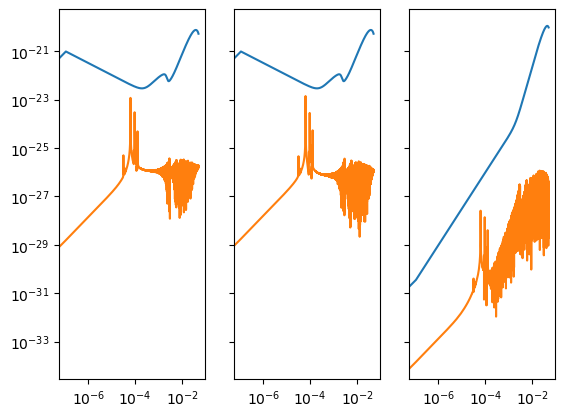

In [41]:
analysis.loglog()
# plt.ylim(1e-24,1e-20)
# plt.xlim(1e-5,1e-2


In [25]:
np.savez("parameters.npz", **new_pars)

# Load
data = np.load("parameters.npz")
parameters = dict(data)

In [26]:
AET= run_emri(new_pars)


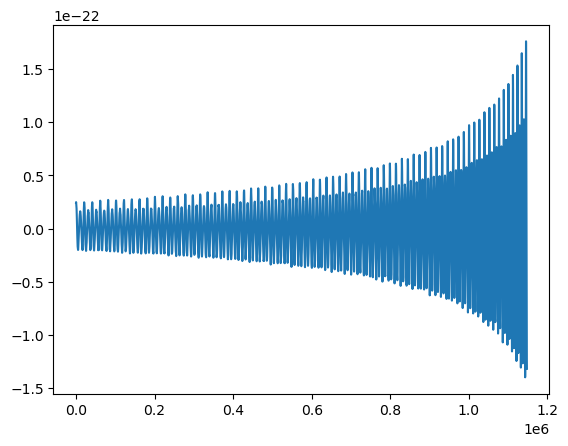

In [27]:
not_z=np.argmax(AET[0][::-1]!=0)
in_dex=(len(AET[0])-not_z)
plt.plot(np.arange(int(in_dex) )* 10, AET[0].real[:int(in_dex)])
# plt.xlim(1.1e6,1.2e6)


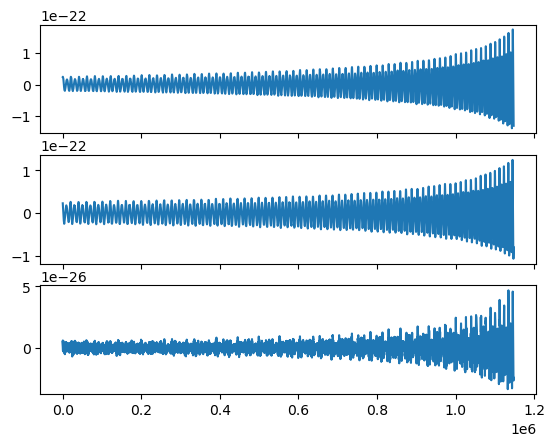

In [28]:
fig, ax = plt.subplots(3, 1, sharex=True)
dt=10
for i in range(3):
    
    ax[i].plot(np.arange(len(AET[0]))* dt, AET[i].real)

In [ ]:
# from lisatools.sources.emri import EMRITDIWaveform
# # imports
# from few.waveform import GenerateEMRIWaveform
# bh=1

# parameters = {
#     'T': 2 / 52,  # duration in years
#     'dt': 10.0,  # timestep in seconds
#     'M': m1[bh],  # primary mass
#     'a': 0.0,  # spin, ignored in Schwarzschild waveform
#     'mu': m2[bh],  # secondary mass
#     'p0': 15,  # initial semi-latus rectum
#     'e0': 0,  # initial eccentricity
#     'x0': 1.0,  # initial frequency param, ignored in Schwarzschild
#     'qK': 0.0,  # polar spin angle
#     'phiK': 0,  # azimuthal spin angle
#     'qS': 0.3,  # polar sky angle
#     'phiS': 0.3,  # azimuthal sky angle
#     'dist': d_l[bh],  # luminosity distance in Gpc
#     'Phi_phi0': 0.0,  # initial phase
#     'Phi_theta0': 0.0,
#     'Phi_r0': 0.0,
#     'dt': 10,
# }


# AET = run_emri()

# # def t_dur(parameters):
# #     AET = run_emri(parameters)
# #     not_z=np.argmax(AET[0][::-1]!=0)
# #     in_dex=len(AET[0])-not_z
# #     return in_dex*10

# not_z=np.argmax(AET[0][::-1]!=0)
# in_dex=(len(AET[0])-not_z)
# plt.plot(np.arange(int(in_dex) )* 10, AET[0].real[:int(in_dex)])
# fig, ax = plt.subplots(3, 1, sharex=True)

# for i in range(3):
    
#     ax[i].plot(np.arange(len(AET[0]))* dt, AET[i].real)
# fig, ax2 = plt.subplots(3, 1, sharex=True)
# for i in range(3):
    
#     ax2[i].plot(AET[i])
# data = DataResidualArray(AET, dt=dt)
# data.loglog()

TypeError: run_emri() missing 1 required positional argument: 'params'

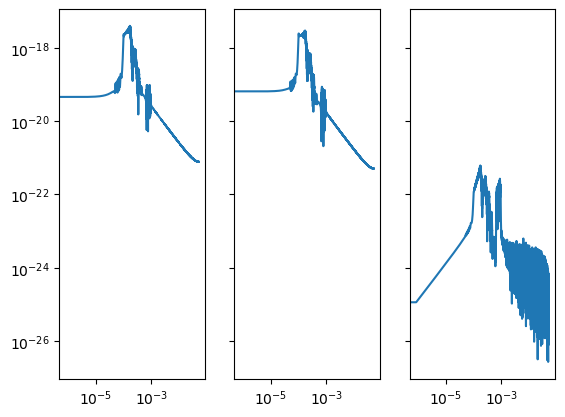

In [29]:
AET = run_emri(new_pars)
data = DataResidualArray(AET, dt=dt)
sens_mat = AET1SensitivityMatrix(data.f_arr, stochastic_params=(4.0 * YRSID_SI,))
data.loglog()
analysis = AnalysisContainer(data, sens_mat, signal_gen=emri_lisa)

(0.0001, 0.1)

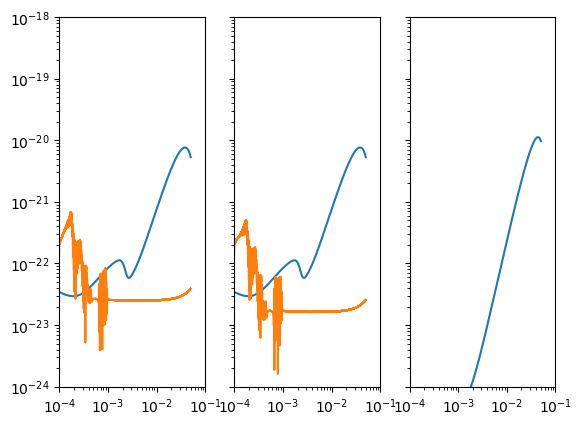

In [30]:
analysis.loglog()
plt.ylim(1e-24,1e-18)
plt.xlim(1e-4,1e-1)

In [31]:
new_pars['mu']=m1[24]/500
new_pars['p0']=16
AET = run_emri(new_pars)
sens_mat = AET1SensitivityMatrix(data.f_arr, stochastic_params=(4.0 * YRSID_SI,))
data = DataResidualArray(AET, dt=dt)
analysis = AnalysisContainer(data, sens_mat, signal_gen=emri_lisa)

/home/karmakar/anaconda3/envs/lisa_env/lib/python3.12/site-packages/few/utils/baseclasses.py:416: UserWarning: Mass ratio is outside of generally accepted range for an extreme mass ratio (1e-4). (q=0.002)
  warnings.warn(


In [32]:
t_dur(new_pars)

np.int64(1147700)

In [33]:
emri_lisa = EMRITDIWaveform(T=5/52,response_kwargs=dict(tdi_chan="AET"))
AET = run_emri(new_pars)
sens_mat = AET1SensitivityMatrix(data.f_arr, stochastic_params=(4.0 * YRSID_SI,))
data = DataResidualArray(AET, dt=dt)
analysis_1 = AnalysisContainer(data, sens_mat, signal_gen=emri_lisa)

In [34]:
emri_lisa = EMRITDIWaveform(T=10/52,response_kwargs=dict(tdi_chan="AET"))
AET = run_emri(new_pars)
sens_mat = AET1SensitivityMatrix(data.f_arr, stochastic_params=(4.0 * YRSID_SI,))
data = DataResidualArray(AET, dt=dt)
analysis_2 = AnalysisContainer(data, sens_mat, signal_gen=emri_lisa)

In [35]:
emri_lisa = EMRITDIWaveform(T=15/52,response_kwargs=dict(tdi_chan="AET"))
AET = run_emri(new_pars)
sens_mat = AET1SensitivityMatrix(data.f_arr, stochastic_params=(4.0 * YRSID_SI,))
data = DataResidualArray(AET, dt=dt)
analysis_3 = AnalysisContainer(data, sens_mat, signal_gen=emri_lisa)

In [36]:
emri_lisa = EMRITDIWaveform(T=20/52,response_kwargs=dict(tdi_chan="AET"))
AET = run_emri(new_pars)
sens_mat = AET1SensitivityMatrix(data.f_arr, stochastic_params=(4.0 * YRSID_SI,))
data = DataResidualArray(AET, dt=dt)
analysis_4 = AnalysisContainer(data, sens_mat, signal_gen=emri_lisa)

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

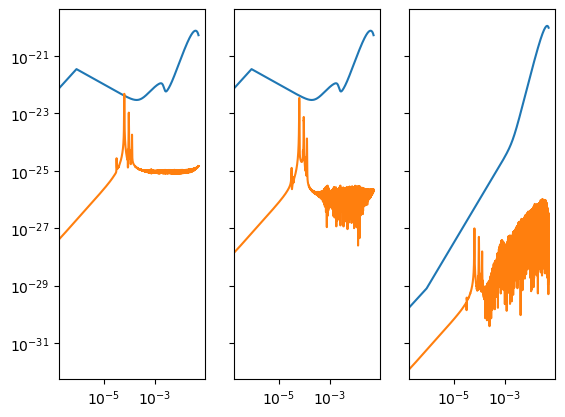

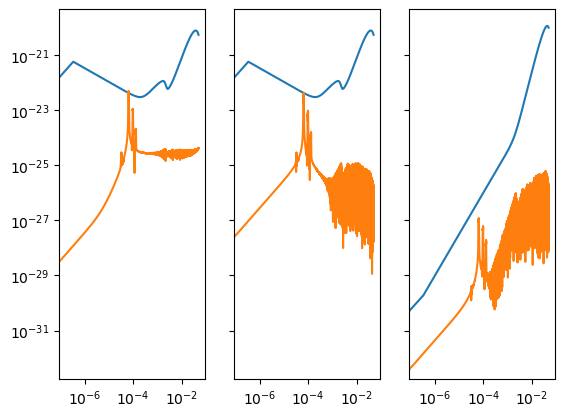

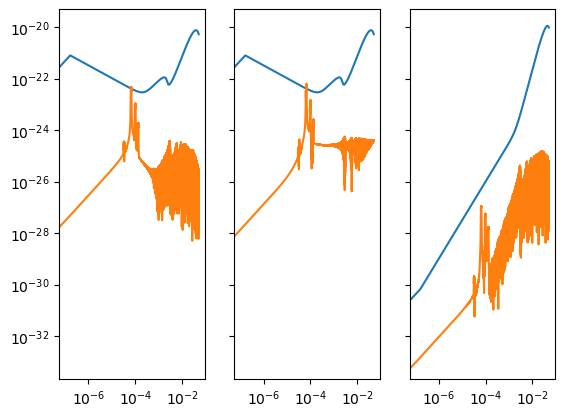

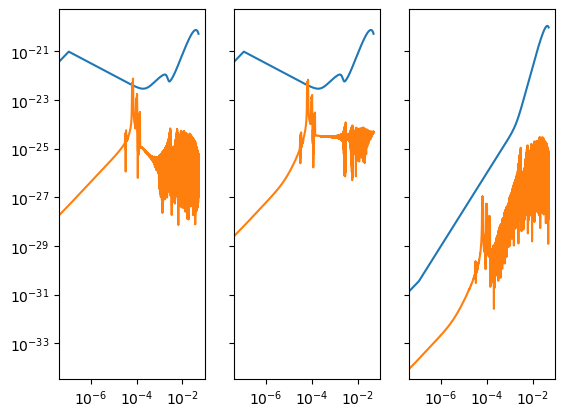

In [37]:
fig, ax = analysis_1.loglog()
analysis_2.loglog()
analysis_3.loglog()
analysis_4.loglog()

In [22]:
new_pars=parameters

In [23]:
new_pars

{'T': 0.038461538461538464,
 'dt': 10,
 'M': np.float64(16098815.018076746),
 'a': 0.0,
 'mu': np.float64(260275.98192325394),
 'p0': 16,
 'e0': 0,
 'x0': 1.0,
 'qK': 0.0,
 'phiK': 0,
 'qS': 0.3,
 'phiS': 0.3,
 'dist': np.float64(8.318307088265946),
 'Phi_phi0': 0.0,
 'Phi_theta0': 0.0,
 'Phi_r0': 0.0}

In [48]:
emri_lisa = EMRITDIWaveform(T=2,response_kwargs=dict(tdi_chan="AET"))
new_pars['mu']=m1[24]/100
new_pars['p0']=16
dt=10
new_pars_1=dict(new_pars)
new_pars['mu']=m1[24]/500
new_pars['p0']=16
new_pars_2=dict(new_pars)
AET_1 = run_emri(new_pars_1)
AET_2 = run_emri(new_pars_2)
data = DataResidualArray([AET_1[0],AET_2[0]], dt=dt)

# # data = DataResidualArray(AET, dt=dt)
# sens_mat = AET1SensitivityMatrix(data.f_arr, stochastic_params=(4.0 * YRSID_SI,))
# analysis = AnalysisContainer(data, sens_mat, signal_gen=emri_lisa)

(<Figure size 640x480 with 2 Axes>, array([<Axes: >, <Axes: >], dtype=object))

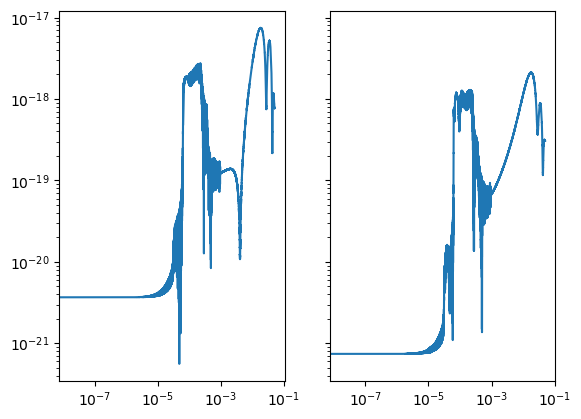

In [49]:
data.loglog()

In [36]:
help(AnalysisContainer)

Help on class AnalysisContainer in module lisatools.analysiscontainer:

class AnalysisContainer(builtins.object)
 |  AnalysisContainer(data_res_arr: 'DataResidualArray', sens_mat: 'SensitivityMatrix', signal_gen: 'Optional[callable]' = None) -> 'None'
 |
 |  Combinatorial container that combines sensitivity and data information.
 |
 |  Args:
 |      data_res_arr: Data / Residual / Signal array.
 |      sens_mat: Sensitivity information.
 |      signal_gen: Callable object that takes information through ``*args`` and ``**kwargs`` and
 |          generates a signal in the proper channel setup employed in ``data_res_arr`` and ``sens_mat``.
 |
 |  Methods defined here:
 |
 |  __init__(self, data_res_arr: 'DataResidualArray', sens_mat: 'SensitivityMatrix', signal_gen: 'Optional[callable]' = None) -> 'None'
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  calculate_signal_inner_product(self, *args: 'Any', source_only: 'bool' = False, waveform_kwargs: 'Optional[di

ValueError: x and y must have same first dimension, but have shapes (603888,) and (1207774,)

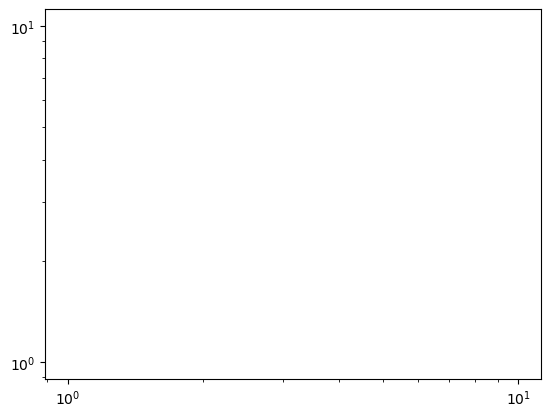

In [28]:

for i, let in enumerate(["A", "E", "T"]):
    plt.loglog(data.f_arr, np.abs(AET[i]), label=let)
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$\tilde{h}(f)$ (Hz$^{-1/2}$)")

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

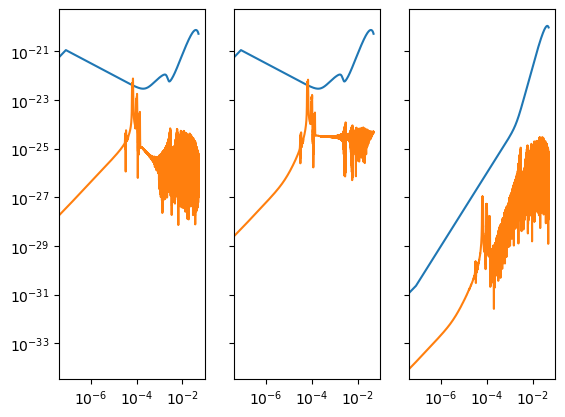

In [ ]:
fig, ax= analysis.loglog()

In [32]:
help(AET[1])

Help on ndarray object:

class ndarray(builtins.object)
 |  ndarray(shape, dtype=float, buffer=None, offset=0,
 |          strides=None, order=None)
 |
 |  An array object represents a multidimensional, homogeneous array
 |  of fixed-size items.  An associated data-type object describes the
 |  format of each element in the array (its byte-order, how many bytes it
 |  occupies in memory, whether it is an integer, a floating point number,
 |  or something else, etc.)
 |
 |  Arrays should be constructed using `array`, `zeros` or `empty` (refer
 |  to the See Also section below).  The parameters given here refer to
 |  a low-level method (`ndarray(...)`) for instantiating an array.
 |
 |  For more information, refer to the `numpy` module and examine the
 |  methods and attributes of an array.
 |
 |  Parameters
 |  ----------
 |  (for the __new__ method; see Notes below)
 |
 |  shape : tuple of ints
 |      Shape of created array.
 |  dtype : data-type, optional
 |      Any object that can

In [ ]:
from bbhx.waveformbuild import BBHWaveformFD

In [ ]:
wave_gen = BBHWaveformFD(amp_phase_kwargs=dict(run_phenomd=False))

Text(0, 0.5, '$\\tilde{h}(f)$ (Hz$^{-1/2}$)')

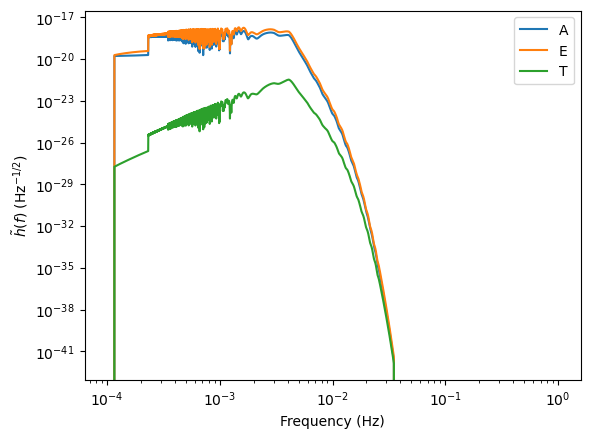

In [ ]:
f_ref = 0.0  # let phenom codes uset f_ref -> fmax = max(f^2A(f))
phi_ref = 0.0 # phase at f_ref
m1_ =m1[30] 
m2_ =m2[30]
a1 = 0.2
a2 = 0.4
dist = d_l[30] # 3e3 in Mpc
inc = np.pi/3.
beta = np.pi/4.  # ecliptic latitude
lam = np.pi/5.  # ecliptic longitude
psi = np.pi/6.  # polarization angle
t_ref = 2/52 * YRSID_SI  # t_ref  (in the SSB reference frame)

# frequencies to interpolate to
freq_new = np.logspace(-4, 0, 10000)
modes = [(2,2), (2,1), (3,3), (3,2), (4,4), (4,3)]

wave = wave_gen(m1_, m2_, a1, a2,
                          dist, phi_ref, f_ref, inc, lam,
                          beta, psi, t_ref, freqs=freq_new,
                          modes=modes, direct=False, fill=True, squeeze=True, length=1024)[0]

for i, let in enumerate(["A", "E", "T"]):
    plt.loglog(freq_new, np.abs(wave[i]), label=let)
plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"$\tilde{h}(f)$ (Hz$^{-1/2}$)")

ecentricity=0
non spinning
p= 
minimum comparable
start with a comparison